# 第 6 章 · 规则链推理代码实验

[章节网页](../ch6.html)

## 运行内容

- 准备事实与规则表
- 运行前向链和后向链
- 展示推理轨迹与规则图

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import subprocess
import sys
import warnings
from collections import defaultdict, deque
from pathlib import Path

required_packages = {
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备一组可追踪的规则：每条规则由前提 facts 和结论 then 组成。
initial_facts = {"今天下雨", "有雨伞", "需要外出"}
goal = "适合带伞出门"

rules = [
    {"id": "R1", "facts": ["今天下雨"], "then": "路面湿"},
    {"id": "R2", "facts": ["今天下雨", "需要外出"], "then": "可能淋湿"},
    {"id": "R3", "facts": ["可能淋湿", "有雨伞"], "then": "适合带伞出门"},
    {"id": "R4", "facts": ["路面湿"], "then": "行走速度变慢"},
]

facts_df = pd.DataFrame({"初始事实": sorted(initial_facts)})
rules_df = pd.DataFrame(
    [
        {"规则": rule["id"], "前提": " + ".join(rule["facts"]), "结论": rule["then"]}
        for rule in rules
    ]
)

display(facts_df)
display(rules_df)

,初始事实
0,今天下雨
1,有雨伞
2,需要外出


,规则,前提,结论
0,R1,今天下雨,路面湿
1,R2,今天下雨 + 需要外出,可能淋湿
2,R3,可能淋湿 + 有雨伞,适合带伞出门
3,R4,路面湿,行走速度变慢


## 1. 前向链

In [3]:
# 前向链：从已知事实出发，反复触发前提已满足的规则。
def forward_chain(initial_facts, rules, goal):
    known = set(initial_facts)
    fired = set()
    rows = []
    round_id = 0

    while True:
        candidates = []
        for rule in rules:
            if rule["id"] in fired:
                continue
            missing = [fact for fact in rule["facts"] if fact not in known]
            if not missing:
                candidates.append(rule)

        if not candidates:
            break

        for rule in candidates:
            round_id += 1
            before = set(known)
            known.add(rule["then"])
            fired.add(rule["id"])
            rows.append({
                "轮次": round_id,
                "触发规则": rule["id"],
                "前提": " + ".join(rule["facts"]),
                "新增事实": rule["then"] if rule["then"] not in before else "已存在",
                "已知事实": "、".join(sorted(known)),
                "达到目标": rule["then"] == goal or goal in known,
            })
            if goal in known:
                return known, pd.DataFrame(rows)

    return known, pd.DataFrame(rows)


forward_facts, forward_trace = forward_chain(initial_facts, rules, goal)
display(forward_trace)
print("推理结果:", goal in forward_facts)

,轮次,触发规则,前提,新增事实,已知事实,达到目标
0,1,R1,今天下雨,路面湿,今天下雨、有雨伞、路面湿、需要外出,False
1,2,R2,今天下雨 + 需要外出,可能淋湿,今天下雨、可能淋湿、有雨伞、路面湿、需要外出,False
2,3,R3,可能淋湿 + 有雨伞,适合带伞出门,今天下雨、可能淋湿、有雨伞、路面湿、适合带伞出门、需要外出,True


推理结果: True


## 2. 后向链

In [4]:
# 后向链：从目标倒推需要哪些前提，再逐个证明这些前提。
def backward_chain(goal, initial_facts, rules):
    rows = []
    active = set()

    def prove(target, depth=0):
        if target in initial_facts:
            rows.append({
                "深度": depth,
                "待证明": target,
                "使用规则": "初始事实",
                "子目标": "",
                "结论": "成立",
            })
            return True

        if target in active:
            rows.append({
                "深度": depth,
                "待证明": target,
                "使用规则": "循环依赖",
                "子目标": "",
                "结论": "失败",
            })
            return False

        active.add(target)
        matched = [rule for rule in rules if rule["then"] == target]
        if not matched:
            active.remove(target)
            rows.append({
                "深度": depth,
                "待证明": target,
                "使用规则": "无可用规则",
                "子目标": "",
                "结论": "失败",
            })
            return False

        for rule in matched:
            subgoals = rule["facts"]
            ok = all(prove(item, depth + 1) for item in subgoals)
            rows.append({
                "深度": depth,
                "待证明": target,
                "使用规则": rule["id"],
                "子目标": "、".join(subgoals),
                "结论": "成立" if ok else "失败",
            })
            if ok:
                active.remove(target)
                return True

        active.remove(target)
        return False

    success = prove(goal)
    trace = pd.DataFrame(rows)
    return success, trace.sort_index(ascending=False).reset_index(drop=True)


backward_success, backward_trace = backward_chain(goal, initial_facts, rules)
display(backward_trace)
print("推理结果:", backward_success)

,深度,待证明,使用规则,子目标,结论
0,0,适合带伞出门,R3,可能淋湿、有雨伞,成立
1,1,有雨伞,初始事实,,成立
2,1,可能淋湿,R2,今天下雨、需要外出,成立
3,2,需要外出,初始事实,,成立
4,2,今天下雨,初始事实,,成立


推理结果: True


## 3. 推理路径图

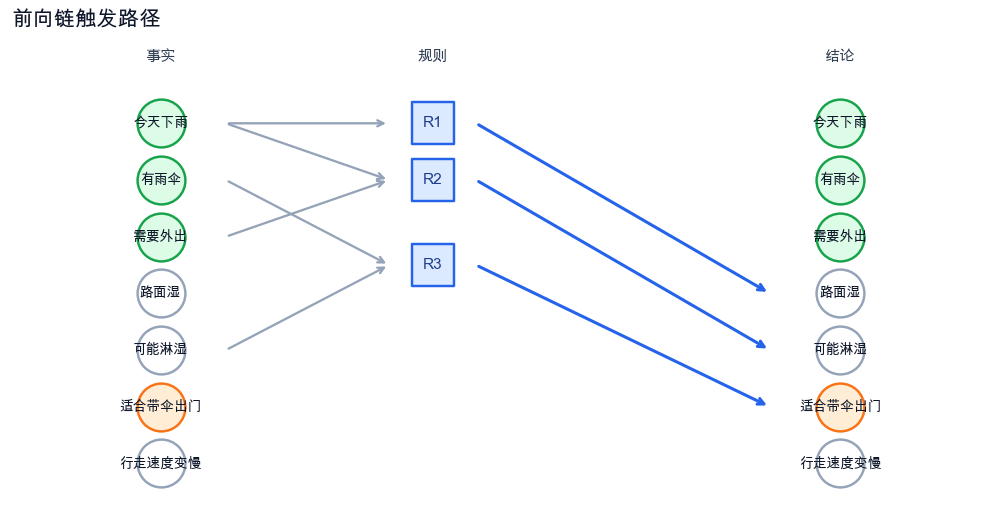

In [5]:
# 画出规则触发路径：绿色节点来自初始事实，蓝色节点是推理得到的新事实。
def draw_rule_flow(initial_facts, rules, trace, title):
    used_rules = set(trace.get("触发规则", [])) | set(trace.get("使用规则", []))
    used_rules.discard("初始事实")
    used_rules.discard("无可用规则")
    used_rules.discard("循环依赖")

    fact_order = list(dict.fromkeys(
        list(sorted(initial_facts)) + [rule["then"] for rule in rules] + [goal]
    ))
    y_lookup = {fact: i for i, fact in enumerate(reversed(fact_order))}

    fig, ax = plt.subplots(figsize=(9.2, 4.8))
    ax.set_facecolor("#fbfcfd")

    for rule in rules:
        if rule["id"] not in used_rules:
            continue
        rx = 1.0
        ry = sum(y_lookup[fact] for fact in rule["facts"]) / len(rule["facts"])
        ax.scatter(rx, ry, s=760, marker="s", color="#dbeafe", edgecolor="#2563eb", linewidth=1.6, zorder=3)
        ax.text(rx, ry, rule["id"], ha="center", va="center", fontweight="bold", color="#1e3a8a", zorder=4)
        for fact in rule["facts"]:
            ax.annotate(
                "",
                xy=(rx - 0.16, ry),
                xytext=(0.24, y_lookup[fact]),
                arrowprops={"arrowstyle": "->", "color": "#94a3b8", "lw": 1.5},
            )
        ax.annotate(
            "",
            xy=(2.24, y_lookup[rule["then"]]),
            xytext=(rx + 0.16, ry),
            arrowprops={"arrowstyle": "->", "color": "#2563eb", "lw": 2.0},
        )

    for fact, y in y_lookup.items():
        is_initial = fact in initial_facts
        is_goal = fact == goal
        color = "#dcfce7" if is_initial else "#ffffff"
        edge = "#16a34a" if is_initial else "#94a3b8"
        if is_goal:
            color, edge = "#ffedd5", "#f97316"
        ax.scatter(0, y, s=980, color=color, edgecolor=edge, linewidth=1.6, zorder=3)
        ax.scatter(2.5, y, s=980, color=color, edgecolor=edge, linewidth=1.6, zorder=3)
        ax.text(0, y, fact, ha="center", va="center", fontsize=9, color="#0f172a", zorder=4)
        ax.text(2.5, y, fact, ha="center", va="center", fontsize=9, color="#0f172a", zorder=4)

    ax.text(0, len(y_lookup) + 0.1, "事实", ha="center", fontweight="bold", color="#334155")
    ax.text(1.0, len(y_lookup) + 0.1, "规则", ha="center", fontweight="bold", color="#334155")
    ax.text(2.5, len(y_lookup) + 0.1, "结论", ha="center", fontweight="bold", color="#334155")
    ax.set_title(title, loc="left", fontsize=14, fontweight="bold", color="#0f172a")
    ax.set_xlim(-0.55, 3.05)
    ax.set_ylim(-0.75, len(y_lookup) + 0.55)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_rule_flow(initial_facts, rules, forward_trace, "前向链触发路径")